# 🏦 Home Credit Default Risk — Exploratory Data Analysis

## Problem Statement

Many people struggle to get loans due to insufficient or non-existent credit histories. **Home Credit** strives to broaden financial inclusion for the unbanked population by providing a positive and safe borrowing experience.

The goal of this competition is to **predict the probability that a loan applicant will default** (fail to repay their loan). This is a **binary classification** problem:
- `TARGET = 1` → Client had payment difficulties (default)
- `TARGET = 0` → Client repaid successfully

**Evaluation metric:** Area Under the ROC Curve (AUC-ROC)

---

## Dataset Files

| File | Description |
|------|-------------|
| `application_train/test.csv` | Main table — one row per loan application |
| `bureau.csv` | Previous credits from other financial institutions |
| `bureau_balance.csv` | Monthly balances of bureau credits |
| `previous_application.csv` | Previous Home Credit loan applications |
| `POS_CASH_balance.csv` | Monthly snapshots of POS/cash loan balances |
| `credit_card_balance.csv` | Monthly snapshots of credit card balances |
| `installments_payments.csv` | Repayment history for prior Home Credit loans |
| `HomeCredit_columns_description.csv` | Column descriptions |

---

## 0. Setup & Imports

In [1]:
import matplotlib
matplotlib.use('Agg')

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

# ── Data path ──────────────────────────────────────────────────────────────────
DATA_PATH = os.path.expanduser('~/.cache/kagglehub/competitions/home-credit-default-risk')
print('Data files found:')
for f in sorted(os.listdir(DATA_PATH)):
    size_mb = os.path.getsize(os.path.join(DATA_PATH, f)) / 1e6
    print(f'  {f:<45} {size_mb:>8.1f} MB')

Data files found:
  HomeCredit_columns_description.csv                 0.0 MB
  POS_CASH_balance.csv                             392.7 MB
  application_test.csv                              26.6 MB
  application_train.csv                            166.1 MB
  bureau.csv                                       170.0 MB
  bureau_balance.csv                               375.6 MB
  credit_card_balance.csv                          424.6 MB
  installments_payments.csv                        723.1 MB
  previous_application.csv                         405.0 MB
  sample_submission.csv                              0.5 MB


---
## 1. Application Train & Test (Main Table)

In [3]:
train = pd.read_csv(os.path.join(DATA_PATH, 'application_train.csv'))
test  = pd.read_csv(os.path.join(DATA_PATH, 'application_test.csv'))

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'\nTrain columns: {train.shape[1]} | Test columns: {test.shape[1]}')
print(f'Difference   : TARGET column (in train only)')

Train shape : (307511, 122)
Test shape  : (48744, 121)

Train columns: 122 | Test columns: 121
Difference   : TARGET column (in train only)


In [4]:
train.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.7296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [5]:
train.dtypes.value_counts().rename('count').to_frame()

,count
float64,65
int64,41
object,16


### 1.1 Target Variable Distribution

In [6]:
target_counts = train['TARGET'].value_counts()
target_pct    = train['TARGET'].value_counts(normalize=True) * 100

print('TARGET Distribution:')
print(pd.DataFrame({'Count': target_counts, 'Percent (%)': target_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Default (0)', 'Default (1)'], target_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Applications')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(target_pct.values, labels=['No Default (0)', 'Default (1)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance in Target Variable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('\n⚠️  Dataset is heavily imbalanced — ~8% defaults. This needs to be addressed during modeling.')

TARGET Distribution:
         Count  Percent (%)
TARGET                     
0       282686      91.9300
1        24825       8.0700

⚠️  Dataset is heavily imbalanced — ~8% defaults. This needs to be addressed during modeling.


### 1.2 Missing Values Analysis

In [7]:
def missing_summary(df, name='DataFrame'):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    result = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
    result = result[result['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f'\n{name}: {result.shape[0]} columns with missing values out of {df.shape[1]}')
    return result

train_missing = missing_summary(train, 'application_train')
print(f'\nTop 20 columns with most missing values:')
display(train_missing.head(20))


application_train: 67 columns with missing values out of 122

Top 20 columns with most missing values:


,Missing Count,Missing %
COMMONAREA_MEDI,214865,69.8700
COMMONAREA_MODE,214865,69.8700
COMMONAREA_AVG,214865,69.8700
NONLIVINGAPARTMENTS_MODE,213514,69.4300
NONLIVINGAPARTMENTS_MEDI,213514,69.4300
NONLIVINGAPARTMENTS_AVG,213514,69.4300
FONDKAPREMONT_MODE,210295,68.3900
LIVINGAPARTMENTS_AVG,210199,68.3500
LIVINGAPARTMENTS_MEDI,210199,68.3500
LIVINGAPARTMENTS_MODE,210199,68.3500


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
top_missing = train_missing.head(30)
bars = ax.barh(top_missing.index[::-1], top_missing['Missing %'][::-1],
               color=plt.cm.RdYlGn_r(top_missing['Missing %'][::-1] / 100))
ax.set_xlabel('Missing %')
ax.set_title('Top 30 Columns by Missing Value % (application_train)', fontsize=13, fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 1.3 Key Numerical Features Distribution

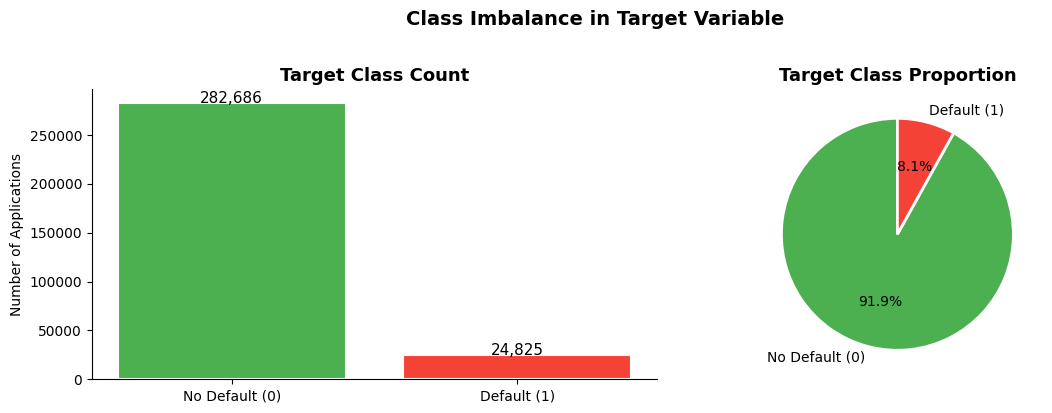

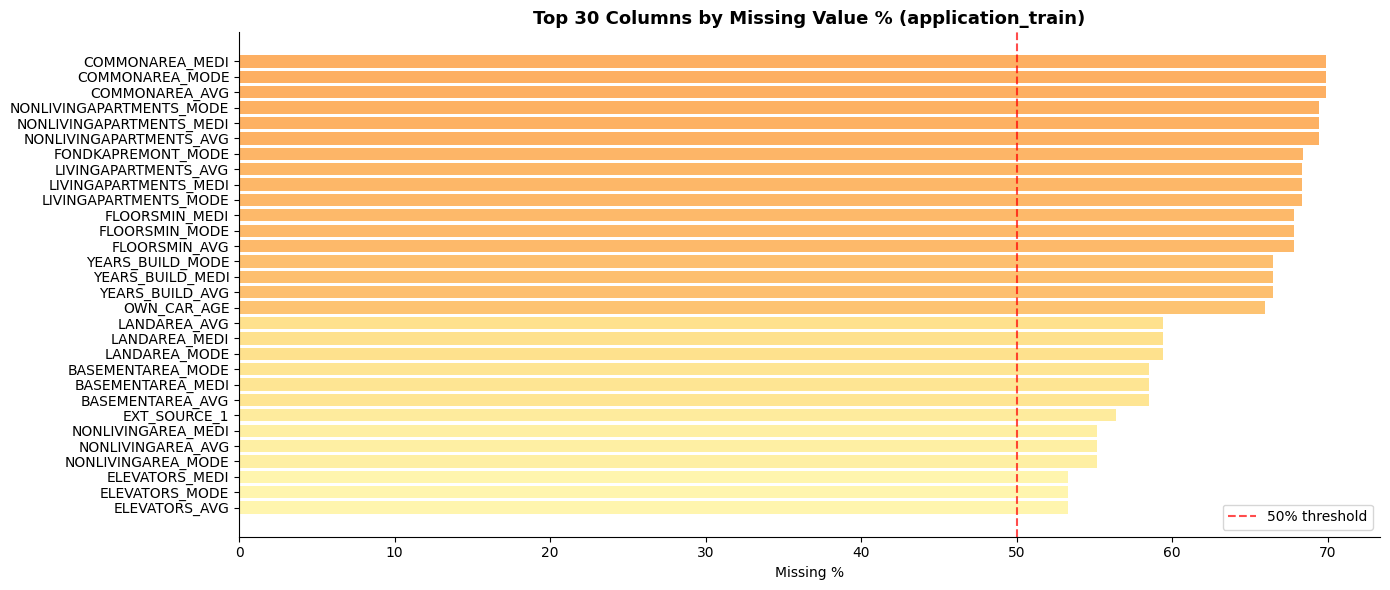

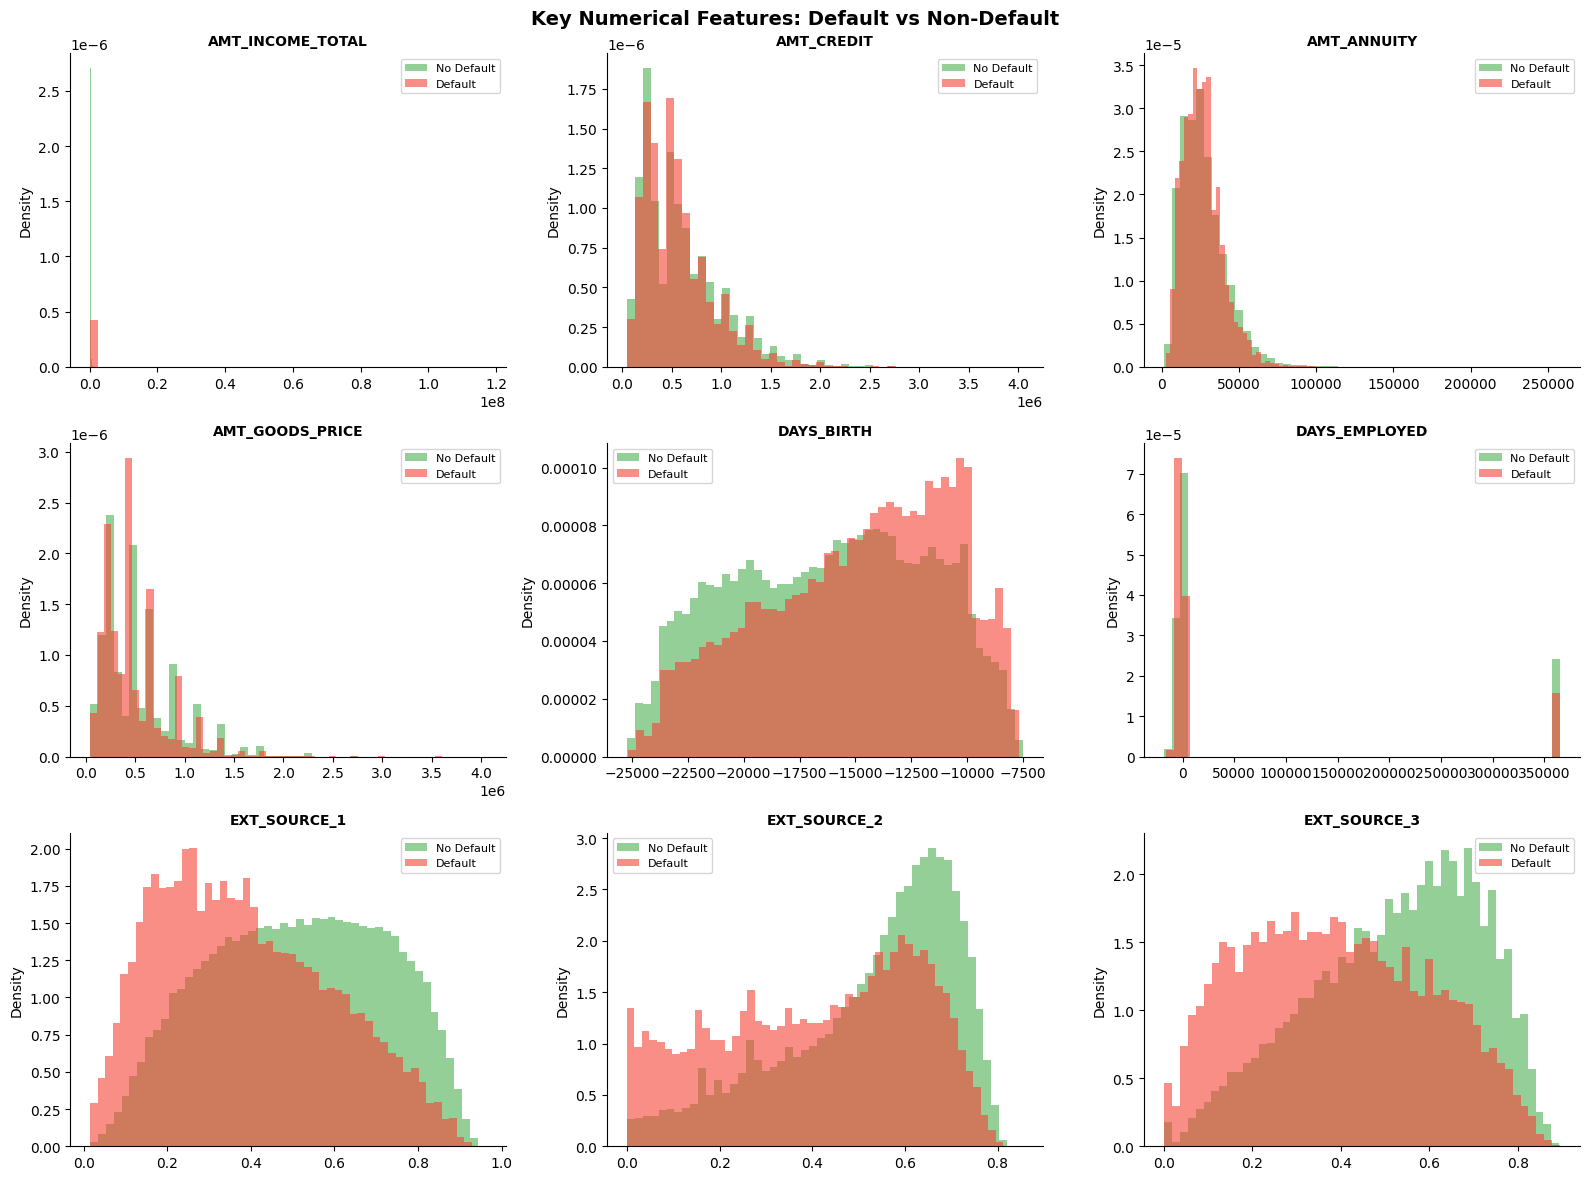

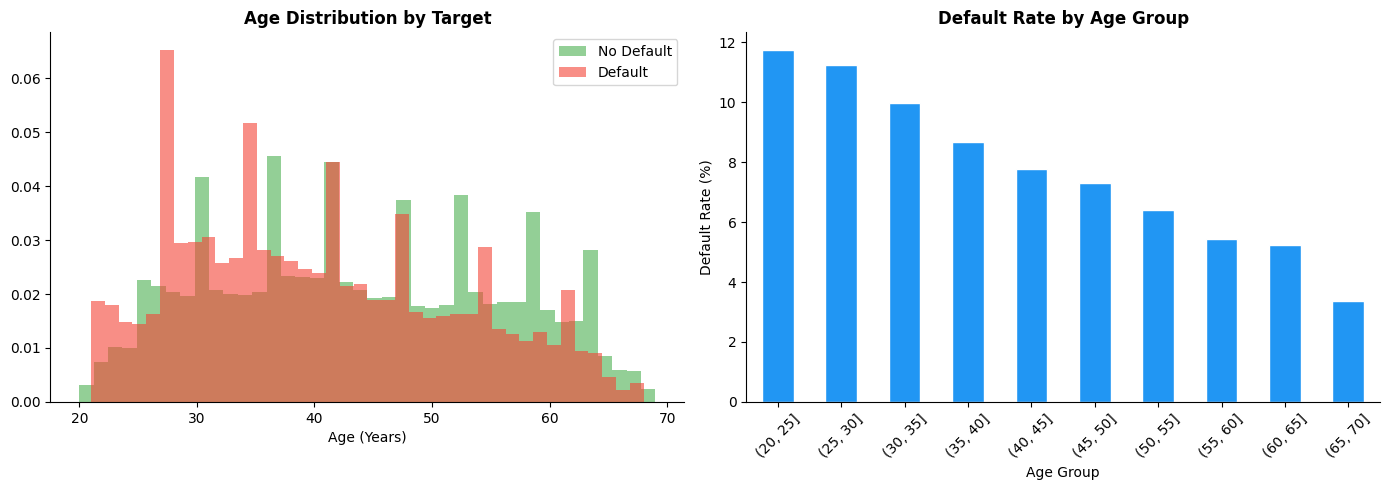

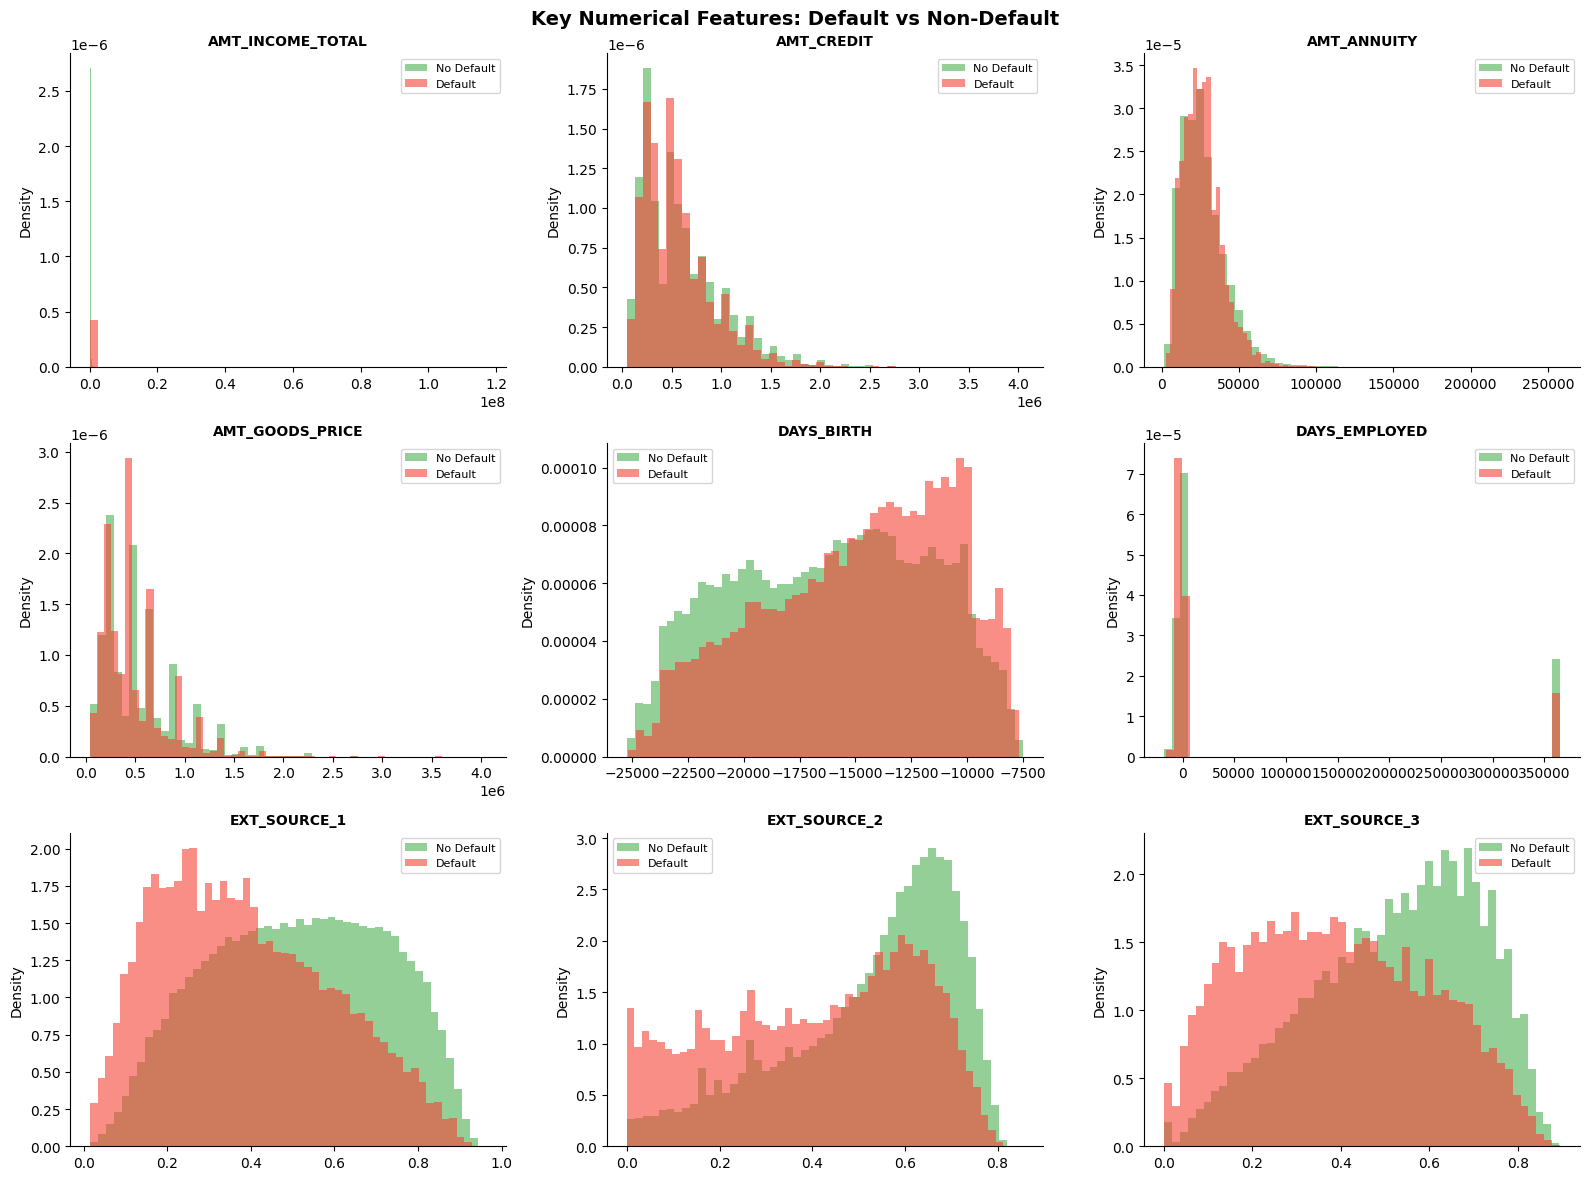

In [11]:
%matplotlib inline          

num_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    if col in train.columns:
        data_0 = train.loc[train['TARGET'] == 0, col].dropna()
        data_1 = train.loc[train['TARGET'] == 1, col].dropna()
        axes[i].hist(data_0, bins=50, alpha=0.6, label='No Default', color='#4CAF50', density=True)
        axes[i].hist(data_1, bins=50, alpha=0.6, label='Default', color='#F44336', density=True)
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].legend(fontsize=8)
        axes[i].set_ylabel('Density')

plt.suptitle('Key Numerical Features: Default vs Non-Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

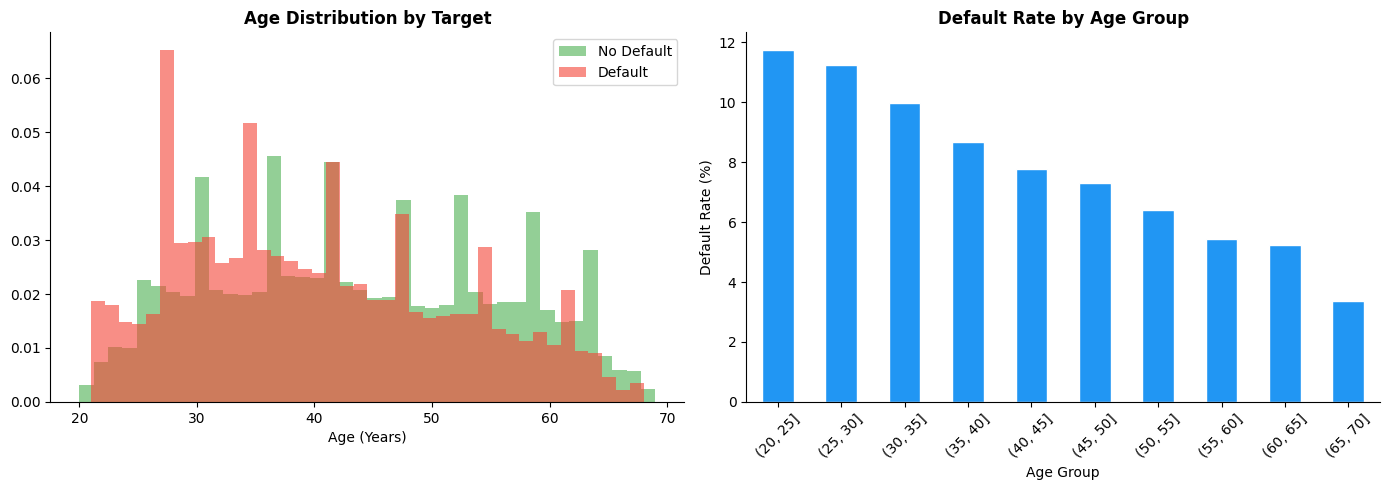

Insight: Younger applicants (20-30) have significantly higher default rates.


In [12]:
%matplotlib inline          
# Age from DAYS_BIRTH (negative days from today)
train['AGE_YEARS'] = (-train['DAYS_BIRTH'] / 365).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(train.loc[train['TARGET']==0, 'AGE_YEARS'], bins=40, alpha=0.6,
             label='No Default', color='#4CAF50', density=True)
axes[0].hist(train.loc[train['TARGET']==1, 'AGE_YEARS'], bins=40, alpha=0.6,
             label='Default', color='#F44336', density=True)
axes[0].set_title('Age Distribution by Target', fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].legend()

# Default rate by age group
train['AGE_BIN'] = pd.cut(train['AGE_YEARS'], bins=[20,25,30,35,40,45,50,55,60,65,70])
age_default = train.groupby('AGE_BIN')['TARGET'].mean() * 100
age_default.plot(kind='bar', ax=axes[1], color='#2196F3', edgecolor='white')
axes[1].set_title('Default Rate by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('Insight: Younger applicants (20-30) have significantly higher default rates.')

### 1.4 Key Categorical Features

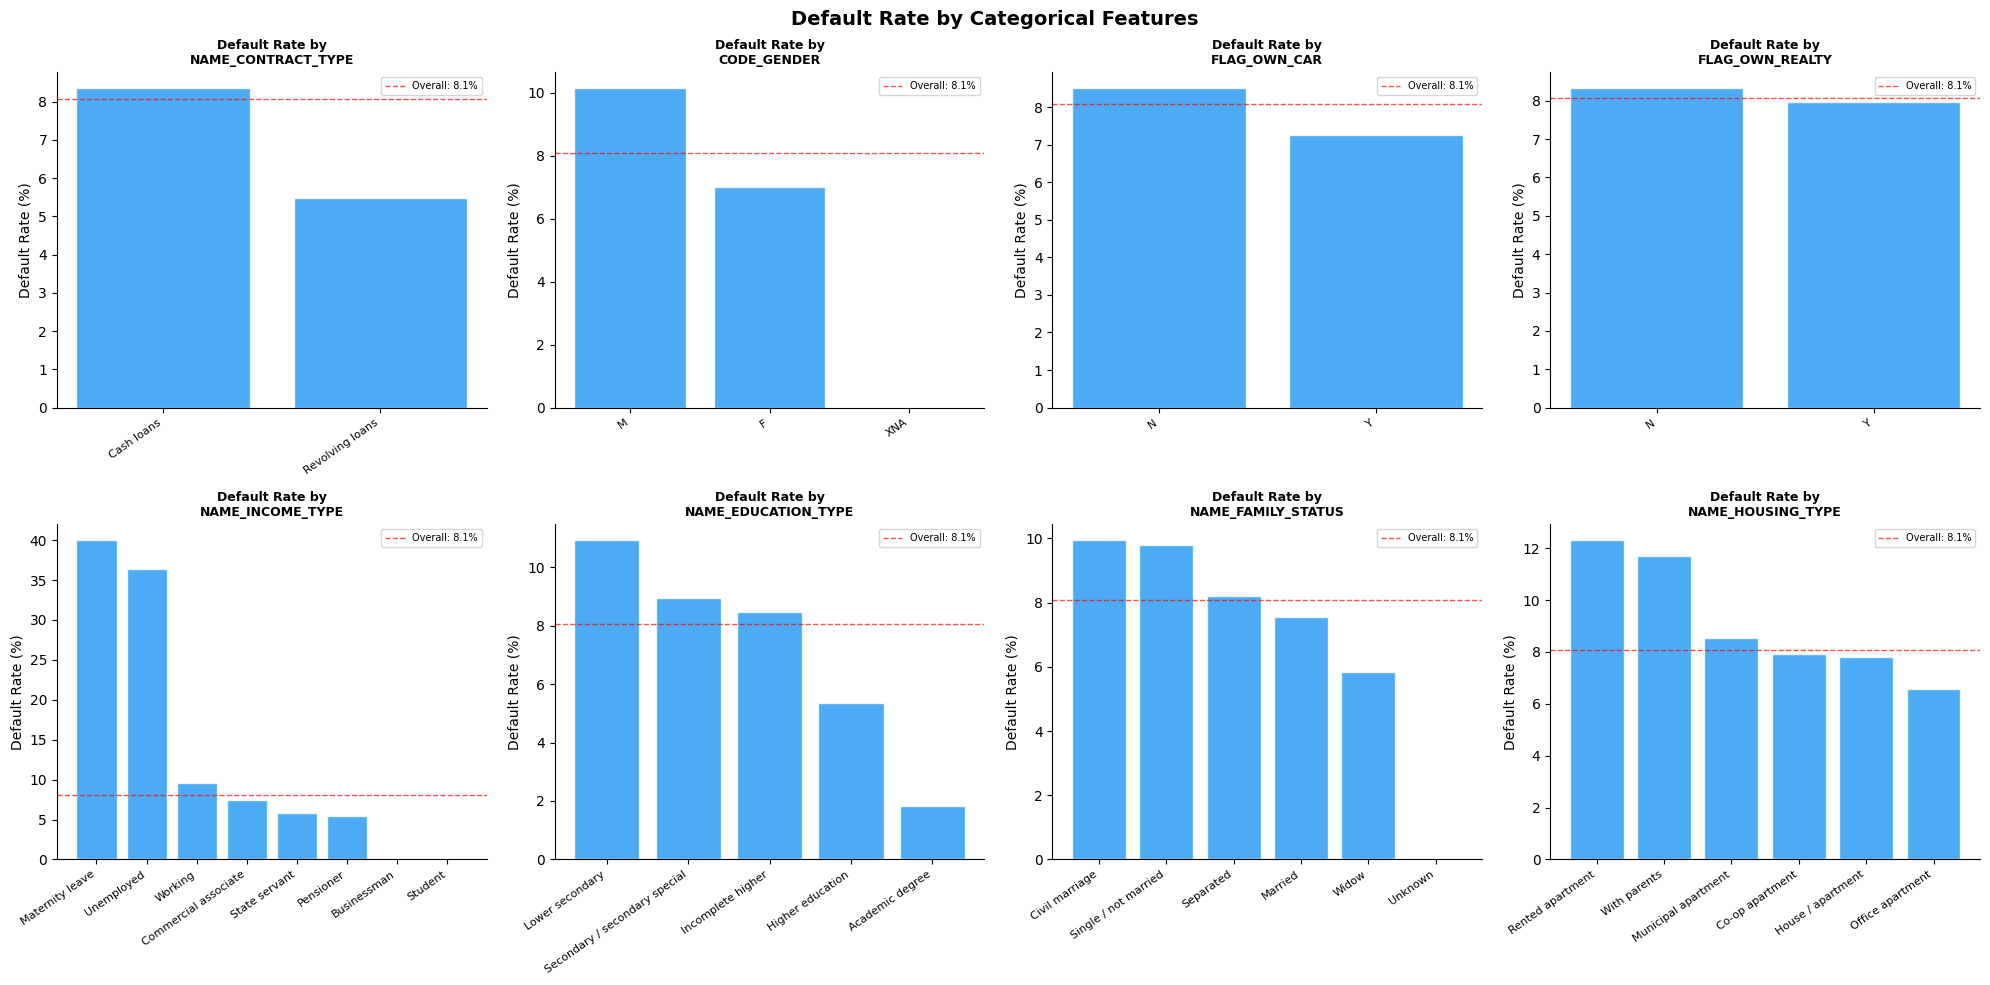

In [13]:
cat_features = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
                'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
                'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    if col in train.columns:
        default_rate = train.groupby(col)['TARGET'].mean().sort_values(ascending=False) * 100
        counts = train[col].value_counts()
        
        bars = axes[i].bar(range(len(default_rate)), default_rate.values,
                           color='#2196F3', edgecolor='white', alpha=0.8)
        axes[i].set_xticks(range(len(default_rate)))
        axes[i].set_xticklabels(default_rate.index, rotation=35, ha='right', fontsize=8)
        axes[i].set_title(f'Default Rate by\n{col}', fontsize=9, fontweight='bold')
        axes[i].set_ylabel('Default Rate (%)')
        axes[i].axhline(train['TARGET'].mean()*100, color='red', linestyle='--',
                        alpha=0.7, linewidth=1, label=f'Overall: {train["TARGET"].mean()*100:.1f}%')
        axes[i].legend(fontsize=7)

plt.suptitle('Default Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.5 External Source Scores (Most Predictive Features)

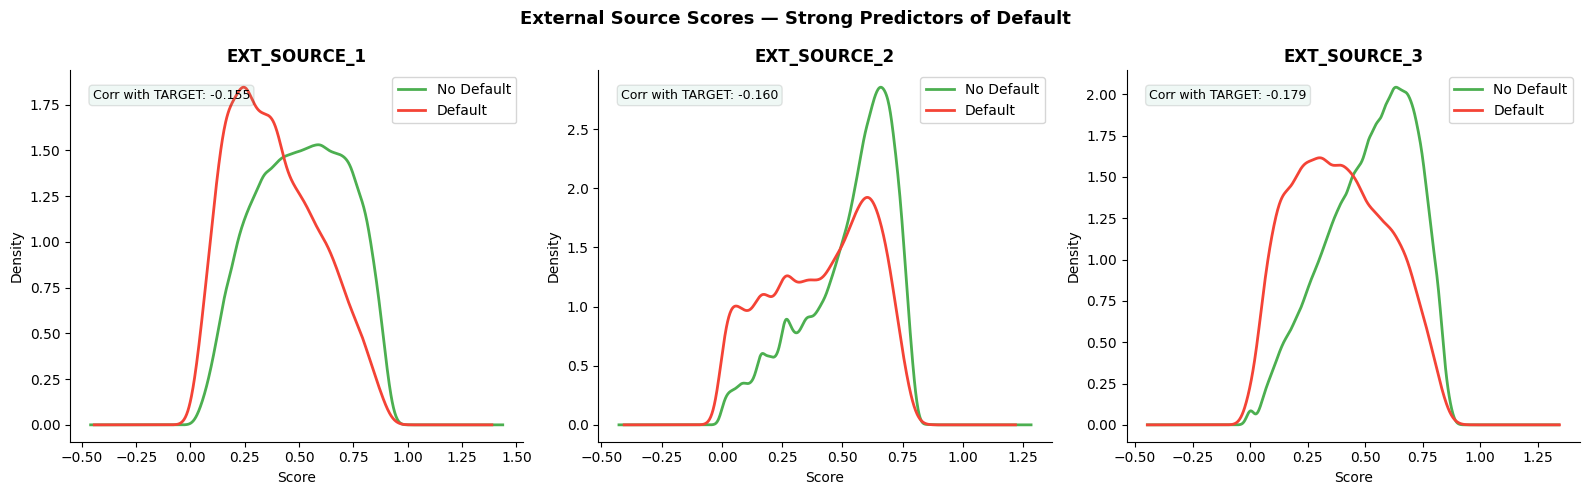

Insight: All three EXT_SOURCE features show clear separation between defaulters and non-defaulters.
Higher scores → lower default probability.


In [14]:
ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(ext_sources):
    if col in train.columns:
        train.loc[train['TARGET']==0, col].dropna().plot(kind='kde', ax=axes[i],
            label='No Default', color='#4CAF50', linewidth=2)
        train.loc[train['TARGET']==1, col].dropna().plot(kind='kde', ax=axes[i],
            label='Default', color='#F44336', linewidth=2)
        axes[i].set_title(f'{col}', fontweight='bold')
        axes[i].legend()
        axes[i].set_xlabel('Score')
        axes[i].set_ylabel('Density')
        
        corr = train[col].corr(train['TARGET'])
        axes[i].text(0.05, 0.95, f'Corr with TARGET: {corr:.3f}',
                     transform=axes[i].transAxes, fontsize=9,
                     verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.1))

plt.suptitle('External Source Scores — Strong Predictors of Default', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Insight: All three EXT_SOURCE features show clear separation between defaulters and non-defaulters.')
print('Higher scores → lower default probability.')

### 1.6 Correlation Heatmap (Numerical Features)

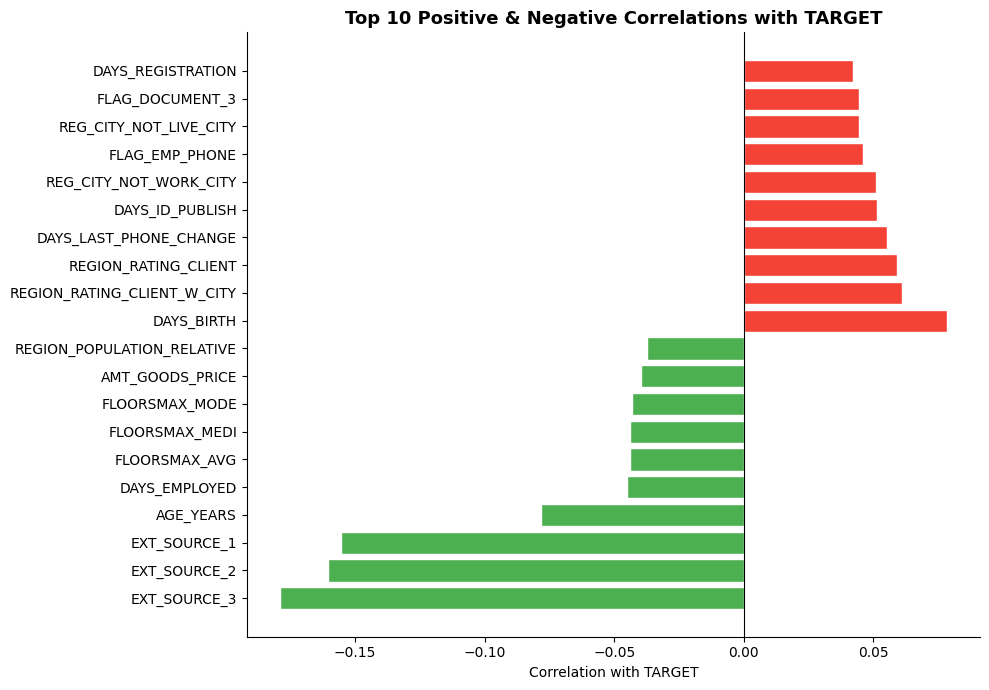

In [15]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# Top features most correlated with TARGET
target_corr = train[num_cols].corr()['TARGET'].drop('TARGET')
top_corr = pd.concat([target_corr.nsmallest(10), target_corr.nlargest(10)])

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#F44336' if x > 0 else '#4CAF50' for x in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors, edgecolor='white')
ax.set_xlabel('Correlation with TARGET')
ax.set_title('Top 10 Positive & Negative Correlations with TARGET', fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 2. Bureau Data

In [16]:
bureau = pd.read_csv(os.path.join(DATA_PATH, 'bureau.csv'))
print(f'Bureau shape: {bureau.shape}')
print(f'Unique applicants: {bureau["SK_ID_CURR"].nunique():,}')
print(f'Avg previous credits per applicant: {bureau.shape[0] / bureau["SK_ID_CURR"].nunique():.1f}')
bureau.head(3)

Bureau shape: (1716428, 17)
Unique applicants: 305,811
Avg previous credits per applicant: 5.6


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0000,-153.0000,NaN,0,91323.0000,0.0000,NaN,0.0000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0000,NaN,NaN,0,225000.0000,171342.0000,NaN,0.0000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0000,NaN,NaN,0,464323.5000,NaN,NaN,0.0000,Consumer credit,-16,NaN


In [17]:
bureau_missing = missing_summary(bureau, 'bureau')
display(bureau_missing.head(10))


bureau: 7 columns with missing values out of 17


,Missing Count,Missing %
AMT_ANNUITY,1226791,71.4700
AMT_CREDIT_MAX_OVERDUE,1124488,65.5100
DAYS_ENDDATE_FACT,633653,36.9200
AMT_CREDIT_SUM_LIMIT,591780,34.4800
AMT_CREDIT_SUM_DEBT,257669,15.0100
DAYS_CREDIT_ENDDATE,105553,6.1500
AMT_CREDIT_SUM,13,0.0000


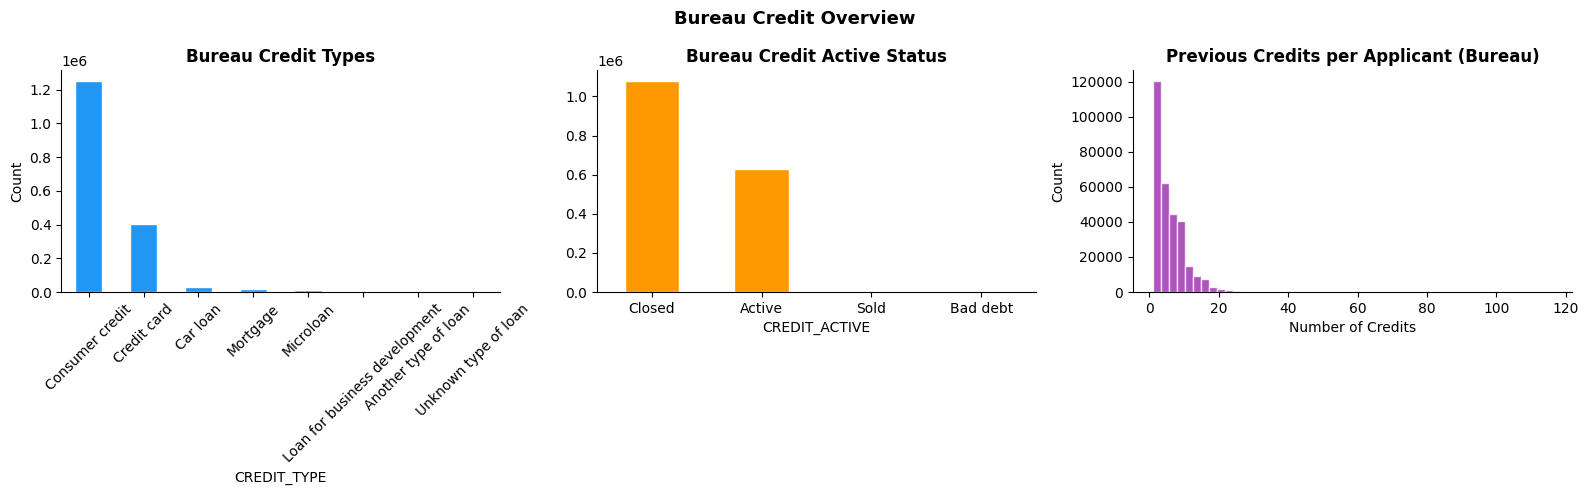

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Credit type distribution
bureau['CREDIT_TYPE'].value_counts().head(8).plot(
    kind='bar', ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Bureau Credit Types', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Count')

# Credit active status
bureau['CREDIT_ACTIVE'].value_counts().plot(
    kind='bar', ax=axes[1], color='#FF9800', edgecolor='white')
axes[1].set_title('Bureau Credit Active Status', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

# Number of previous credits per applicant
credits_per_app = bureau.groupby('SK_ID_CURR').size()
axes[2].hist(credits_per_app, bins=50, color='#9C27B0', edgecolor='white', alpha=0.8)
axes[2].set_title('Previous Credits per Applicant (Bureau)', fontweight='bold')
axes[2].set_xlabel('Number of Credits')
axes[2].set_ylabel('Count')

plt.suptitle('Bureau Credit Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Merge bureau aggregations with train target
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    total_credits=('SK_ID_BUREAU', 'count'),
    active_credits=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    avg_days_credit=('DAYS_CREDIT', 'mean'),
    total_credit_sum=('AMT_CREDIT_SUM', 'sum'),
    total_overdue=('AMT_CREDIT_SUM_OVERDUE', 'sum')
).reset_index()

bureau_with_target = bureau_agg.merge(train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner')

print('Bureau aggregations correlation with TARGET:')
cols = ['total_credits', 'active_credits', 'avg_days_credit', 'total_credit_sum', 'total_overdue']
corr_df = bureau_with_target[cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
print(corr_df.sort_values())

Bureau aggregations correlation with TARGET:
total_credit_sum   -0.0141
total_credits       0.0041
total_overdue       0.0133
active_credits      0.0671
avg_days_credit     0.0897
Name: TARGET, dtype: float64


---
## 3. Bureau Balance

In [20]:
bureau_bal = pd.read_csv(os.path.join(DATA_PATH, 'bureau_balance.csv'))
print(f'Bureau Balance shape: {bureau_bal.shape}')
print(f'Unique bureau credits tracked: {bureau_bal["SK_ID_BUREAU"].nunique():,}')
bureau_bal.head(3)

Bureau Balance shape: (27299925, 3)
Unique bureau credits tracked: 817,395


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C


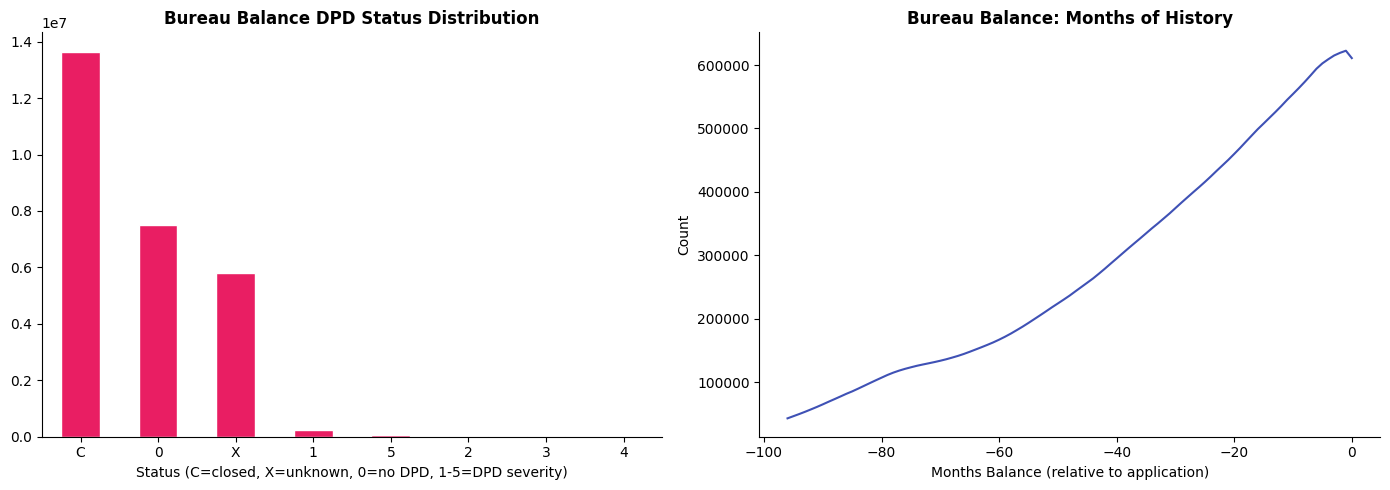

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DPD status distribution
bureau_bal['STATUS'].value_counts().plot(kind='bar', ax=axes[0], color='#E91E63', edgecolor='white')
axes[0].set_title('Bureau Balance DPD Status Distribution', fontweight='bold')
axes[0].set_xlabel('Status (C=closed, X=unknown, 0=no DPD, 1-5=DPD severity)')
axes[0].tick_params(axis='x', rotation=0)

# Months balance
bureau_bal['MONTHS_BALANCE'].value_counts().sort_index().plot(ax=axes[1], color='#3F51B5')
axes[1].set_title('Bureau Balance: Months of History', fontweight='bold')
axes[1].set_xlabel('Months Balance (relative to application)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## 4. Previous Applications

In [22]:
prev_app = pd.read_csv(os.path.join(DATA_PATH, 'previous_application.csv'))
print(f'Previous Application shape: {prev_app.shape}')
print(f'Unique applicants: {prev_app["SK_ID_CURR"].nunique():,}')
print(f'Avg previous applications per applicant: {prev_app.shape[0] / prev_app["SK_ID_CURR"].nunique():.1f}')
prev_app.head(3)

Previous Application shape: (1670214, 37)
Unique applicants: 338,857
Avg previous applications per applicant: 4.9


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.4300,17145.0000,17145.0000,0.0000,17145.0000,SATURDAY,15,Y,1,0.0000,0.1828,0.8673,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0000,middle,POS mobile with interest,365243.0000,-42.0000,300.0000,-42.0000,-37.0000,0.0000
1,2802425,108129,Cash loans,25188.6150,607500.0000,679671.0000,NaN,607500.0000,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0000,low_action,Cash X-Sell: low,365243.0000,-134.0000,916.0000,365243.0000,365243.0000,1.0000
2,2523466,122040,Cash loans,15060.7350,112500.0000,136444.5000,NaN,112500.0000,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0000,high,Cash X-Sell: high,365243.0000,-271.0000,59.0000,365243.0000,365243.0000,1.0000


In [23]:
prev_missing = missing_summary(prev_app, 'previous_application')
display(prev_missing.head(10))


previous_application: 16 columns with missing values out of 37


,Missing Count,Missing %
RATE_INTEREST_PRIVILEGED,1664263,99.6400
RATE_INTEREST_PRIMARY,1664263,99.6400
AMT_DOWN_PAYMENT,895844,53.6400
RATE_DOWN_PAYMENT,895844,53.6400
NAME_TYPE_SUITE,820405,49.1200
DAYS_LAST_DUE,673065,40.3000
DAYS_FIRST_DRAWING,673065,40.3000
DAYS_FIRST_DUE,673065,40.3000
DAYS_TERMINATION,673065,40.3000
NFLAG_INSURED_ON_APPROVAL,673065,40.3000


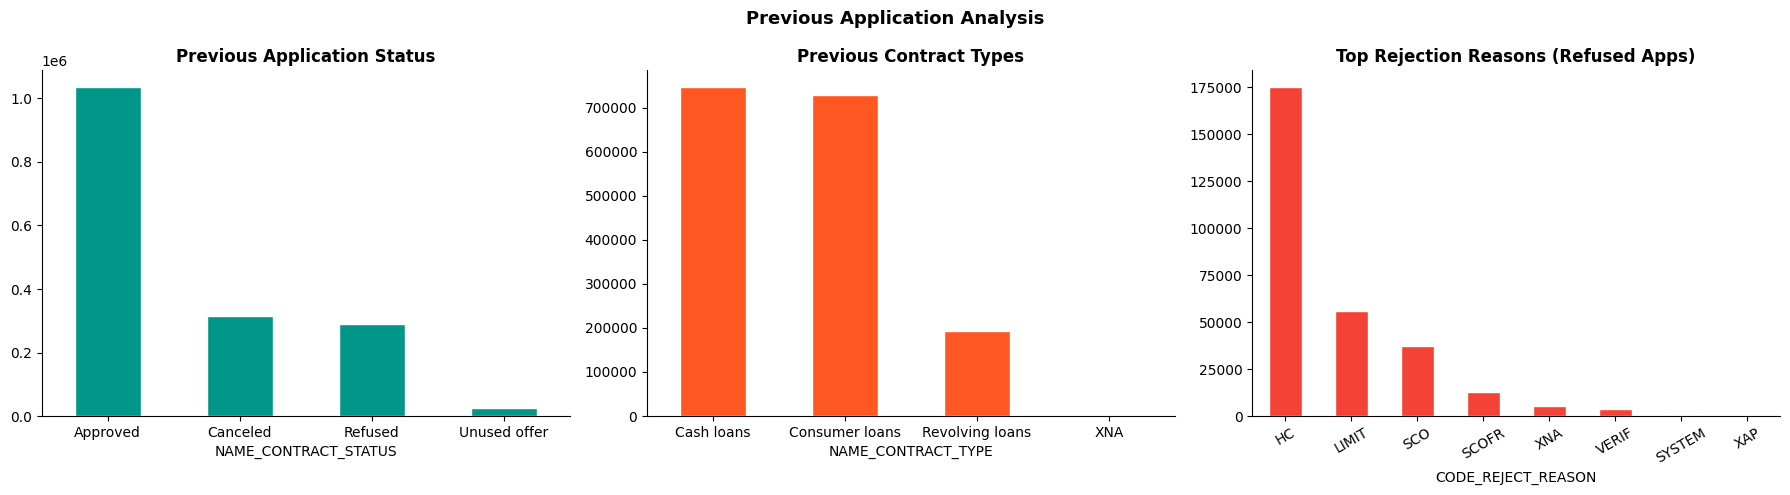

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Contract status
prev_app['NAME_CONTRACT_STATUS'].value_counts().plot(
    kind='bar', ax=axes[0], color='#009688', edgecolor='white')
axes[0].set_title('Previous Application Status', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

# Contract type
prev_app['NAME_CONTRACT_TYPE'].value_counts().plot(
    kind='bar', ax=axes[1], color='#FF5722', edgecolor='white')
axes[1].set_title('Previous Contract Types', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

# Refused reason
prev_app[prev_app['NAME_CONTRACT_STATUS']=='Refused']['CODE_REJECT_REASON'].value_counts().head(8).plot(
    kind='bar', ax=axes[2], color='#F44336', edgecolor='white')
axes[2].set_title('Top Rejection Reasons (Refused Apps)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Previous Application Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

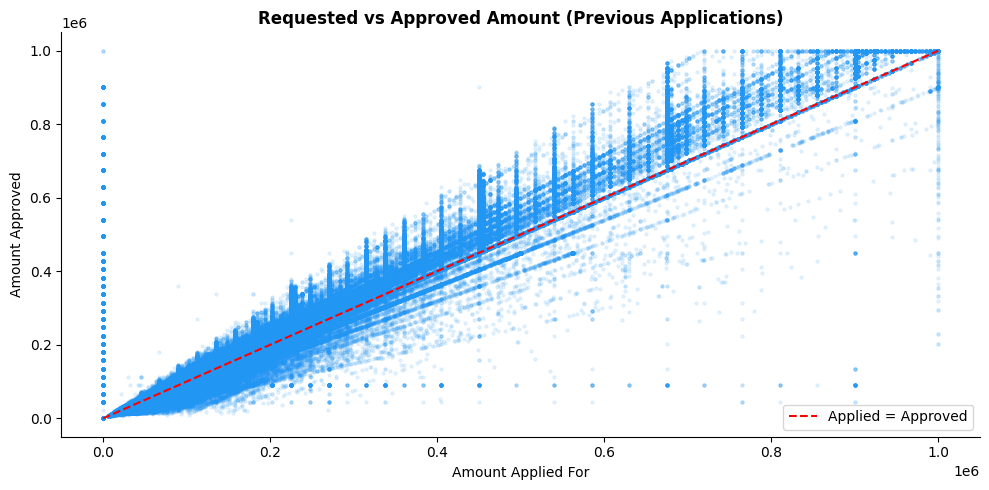

In [25]:
# Credit amount requested vs approved
fig, ax = plt.subplots(figsize=(10, 5))
approved = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Approved']

ax.scatter(approved['AMT_APPLICATION'].clip(upper=1e6),
           approved['AMT_CREDIT'].clip(upper=1e6),
           alpha=0.1, s=5, color='#2196F3')
ax.plot([0, 1e6], [0, 1e6], 'r--', linewidth=1.5, label='Applied = Approved')
ax.set_xlabel('Amount Applied For')
ax.set_ylabel('Amount Approved')
ax.set_title('Requested vs Approved Amount (Previous Applications)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. POS CASH Balance

In [26]:
pos_cash = pd.read_csv(os.path.join(DATA_PATH, 'POS_CASH_balance.csv'))
print(f'POS CASH Balance shape: {pos_cash.shape}')
print(f'Unique applicants: {pos_cash["SK_ID_CURR"].nunique():,}')
pos_cash.head(3)

POS CASH Balance shape: (10001358, 8)
Unique applicants: 337,252


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0000,45.0000,Active,0,0
1,1715348,367990,-33,36.0000,35.0000,Active,0,0
2,1784872,397406,-32,12.0000,9.0000,Active,0,0


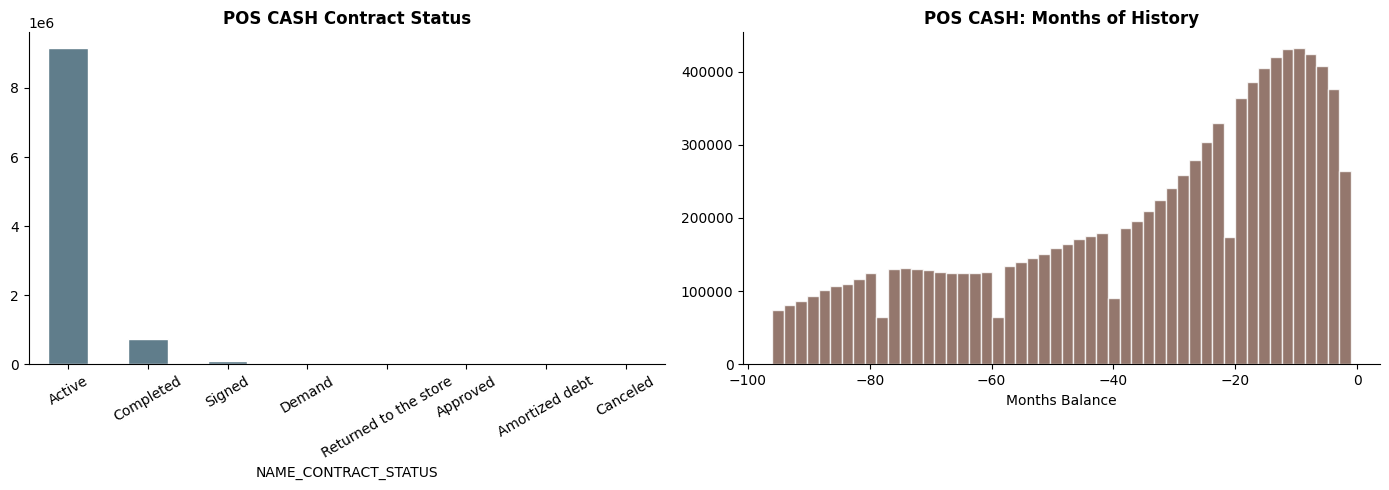

POS CASH correlations with TARGET:
avg_dpd       0.0054
max_dpd       0.0048
avg_dpd_def   0.0065
Name: TARGET, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract status
pos_cash['NAME_CONTRACT_STATUS'].value_counts().head(8).plot(
    kind='bar', ax=axes[0], color='#607D8B', edgecolor='white')
axes[0].set_title('POS CASH Contract Status', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Months balance distribution
axes[1].hist(pos_cash['MONTHS_BALANCE'], bins=50, color='#795548', edgecolor='white', alpha=0.8)
axes[1].set_title('POS CASH: Months of History', fontweight='bold')
axes[1].set_xlabel('Months Balance')

# Merge with target for insight
pos_agg = pos_cash.groupby('SK_ID_CURR').agg(
    pos_records=('SK_ID_PREV', 'count'),
    avg_dpd=('SK_DPD', 'mean'),
    max_dpd=('SK_DPD', 'max'),
    avg_dpd_def=('SK_DPD_DEF', 'mean')
).reset_index()

pos_with_target = pos_agg.merge(train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner')

plt.tight_layout()
plt.show()

print('POS CASH correlations with TARGET:')
print(pos_with_target[['avg_dpd', 'max_dpd', 'avg_dpd_def', 'TARGET']].corr()['TARGET'].drop('TARGET'))

---
## 6. Credit Card Balance

In [28]:
cc_bal = pd.read_csv(os.path.join(DATA_PATH, 'credit_card_balance.csv'))
print(f'Credit Card Balance shape: {cc_bal.shape}')
print(f'Unique applicants: {cc_bal["SK_ID_CURR"].nunique():,}')
cc_bal.head(3)

Credit Card Balance shape: (3840312, 23)
Unique applicants: 103,558


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.9700,135000,0.0000,877.5000,0.0000,877.5000,1700.3250,1800.0000,1800.0000,0.0000,0.0000,0.0000,0.0000,1,0.0000,1.0000,35.0000,Active,0,0
1,2582071,363914,-1,63975.5550,45000,2250.0000,2250.0000,0.0000,0.0000,2250.0000,2250.0000,2250.0000,60175.0800,64875.5550,64875.5550,1.0000,1,0.0000,0.0000,69.0000,Active,0,0
2,1740877,371185,-7,31815.2250,450000,0.0000,0.0000,0.0000,0.0000,2250.0000,2250.0000,2250.0000,26926.4250,31460.0850,31460.0850,0.0000,0,0.0000,0.0000,30.0000,Active,0,0


In [29]:
cc_missing = missing_summary(cc_bal, 'credit_card_balance')
display(cc_missing.head(10))


credit_card_balance: 9 columns with missing values out of 23


,Missing Count,Missing %
AMT_PAYMENT_CURRENT,767988,20.0000
AMT_DRAWINGS_ATM_CURRENT,749816,19.5200
AMT_DRAWINGS_OTHER_CURRENT,749816,19.5200
AMT_DRAWINGS_POS_CURRENT,749816,19.5200
CNT_DRAWINGS_ATM_CURRENT,749816,19.5200
CNT_DRAWINGS_POS_CURRENT,749816,19.5200
CNT_DRAWINGS_OTHER_CURRENT,749816,19.5200
AMT_INST_MIN_REGULARITY,305236,7.9500
CNT_INSTALMENT_MATURE_CUM,305236,7.9500


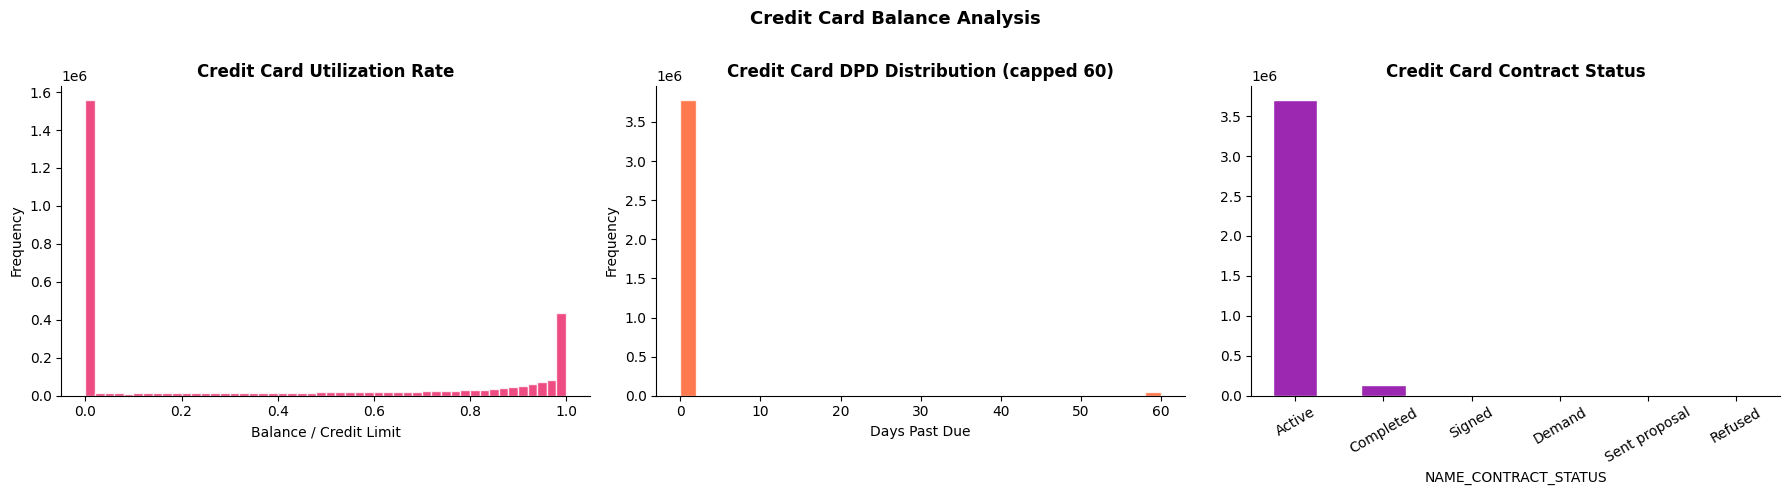

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Balance utilization rate
cc_bal['UTILIZATION'] = cc_bal['AMT_BALANCE'] / cc_bal['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
cc_bal['UTILIZATION'].clip(0, 1).dropna().plot(kind='hist', bins=50, ax=axes[0],
    color='#E91E63', edgecolor='white', alpha=0.8)
axes[0].set_title('Credit Card Utilization Rate', fontweight='bold')
axes[0].set_xlabel('Balance / Credit Limit')

# DPD distribution
cc_bal['SK_DPD'].clip(0, 60).plot(kind='hist', bins=30, ax=axes[1],
    color='#FF5722', edgecolor='white', alpha=0.8)
axes[1].set_title('Credit Card DPD Distribution (capped 60)', fontweight='bold')
axes[1].set_xlabel('Days Past Due')

# Contract status
cc_bal['NAME_CONTRACT_STATUS'].value_counts().head(6).plot(
    kind='bar', ax=axes[2], color='#9C27B0', edgecolor='white')
axes[2].set_title('Credit Card Contract Status', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Credit Card Balance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Installments Payments

In [31]:
inst = pd.read_csv(os.path.join(DATA_PATH, 'installments_payments.csv'))
print(f'Installments Payments shape: {inst.shape}')
print(f'Unique applicants: {inst["SK_ID_CURR"].nunique():,}')
inst.head(3)

Installments Payments shape: (13605401, 8)
Unique applicants: 339,587


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0000,6,-1180.0000,-1187.0000,6948.3600,6948.3600
1,1330831,151639,0.0000,34,-2156.0000,-2156.0000,1716.5250,1716.5250
2,2085231,193053,2.0000,1,-63.0000,-63.0000,25425.0000,25425.0000


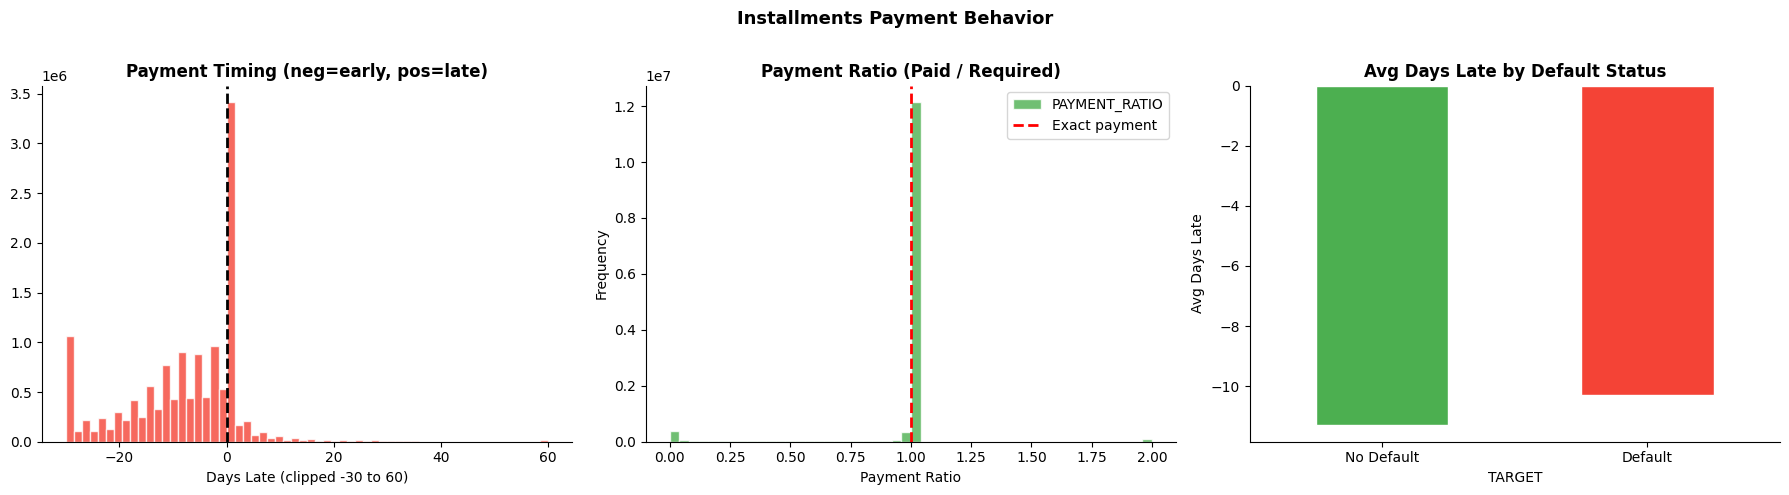

Installments correlations with TARGET:
avg_days_late       0.0209
pct_late            0.0700
avg_payment_ratio   0.0014
Name: TARGET, dtype: float64


In [32]:
# Payment behavior analysis
inst['DAYS_LATE'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['PAYMENT_RATIO'] = inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT'].replace(0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Days late distribution
late_data = inst['DAYS_LATE'].clip(-30, 60)
axes[0].hist(late_data, bins=60, color='#F44336', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Payment Timing (neg=early, pos=late)', fontweight='bold')
axes[0].set_xlabel('Days Late (clipped -30 to 60)')

# Payment ratio
inst['PAYMENT_RATIO'].clip(0, 2).dropna().plot(kind='hist', bins=50, ax=axes[1],
    color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].axvline(1, color='red', linestyle='--', linewidth=2, label='Exact payment')
axes[1].set_title('Payment Ratio (Paid / Required)', fontweight='bold')
axes[1].set_xlabel('Payment Ratio')
axes[1].legend()

# Pct of late payments per applicant
inst_agg = inst.groupby('SK_ID_CURR').agg(
    num_installments=('NUM_INSTALMENT_NUMBER', 'count'),
    avg_days_late=('DAYS_LATE', 'mean'),
    pct_late=('DAYS_LATE', lambda x: (x > 0).mean()),
    avg_payment_ratio=('PAYMENT_RATIO', 'mean')
).reset_index()

inst_with_target = inst_agg.merge(train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner')

inst_with_target.groupby('TARGET')['avg_days_late'].mean().plot(
    kind='bar', ax=axes[2], color=['#4CAF50', '#F44336'], edgecolor='white')
axes[2].set_title('Avg Days Late by Default Status', fontweight='bold')
axes[2].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[2].set_ylabel('Avg Days Late')

plt.suptitle('Installments Payment Behavior', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Installments correlations with TARGET:')
print(inst_with_target[['avg_days_late', 'pct_late', 'avg_payment_ratio', 'TARGET']].corr()['TARGET'].drop('TARGET'))

---
## 8. Column Descriptions

In [33]:
col_desc = pd.read_csv(os.path.join(DATA_PATH, 'HomeCredit_columns_description.csv'),
                       encoding='latin-1')
print(f'Column descriptions shape: {col_desc.shape}')
col_desc.head(10)

Column descriptions shape: (219, 5)


,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,NaN
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN


In [34]:
# Look up descriptions for key features
key_features = ['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
                'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED']

desc_col = col_desc.columns[col_desc.columns.str.lower().isin(['row', 'column', 'feature', 'variable'])].tolist()
if desc_col:
    print(col_desc[col_desc[desc_col[0]].isin(key_features)][col_desc.columns[:3]])
else:
    print(col_desc.columns.tolist())
    display(col_desc.head(20))

     Unnamed: 0                         Table            Row
1             2  application_{train|test}.csv         TARGET
8            11  application_{train|test}.csv     AMT_CREDIT
9            12  application_{train|test}.csv    AMT_ANNUITY
17           20  application_{train|test}.csv     DAYS_BIRTH
18           21  application_{train|test}.csv  DAYS_EMPLOYED
41           44  application_{train|test}.csv   EXT_SOURCE_1
42           45  application_{train|test}.csv   EXT_SOURCE_2
43           46  application_{train|test}.csv   EXT_SOURCE_3
138         141                    bureau.csv    AMT_ANNUITY
176         179      previous_application.csv    AMT_ANNUITY
178         181      previous_application.csv     AMT_CREDIT


---
## 9. Dataset Relationship Overview

In [35]:
tables = {
    'application_train': train,
    'bureau': bureau,
    'bureau_balance': bureau_bal,
    'previous_application': prev_app,
    'POS_CASH_balance': pos_cash,
    'credit_card_balance': cc_bal,
    'installments_payments': inst
}

summary = pd.DataFrame([
    {
        'Table': name,
        'Rows': f'{df.shape[0]:,}',
        'Columns': df.shape[1],
        'Missing Cols': (df.isnull().sum() > 0).sum(),
        'Memory (MB)': f'{df.memory_usage(deep=True).sum() / 1e6:.1f}'
    }
    for name, df in tables.items()
])
print('Dataset Summary:')
display(summary)

Dataset Summary:


,Table,Rows,Columns,Missing Cols,Memory (MB)
0,application_train,"307,511",124,68,532.3
1,bureau,"1,716,428",17,7,495.8
2,bureau_balance,"27,299,925",3,0,1801.8
3,previous_application,"1,670,214",37,16,1785.7
4,POS_CASH_balance,"10,001,358",8,2,1112.5
5,credit_card_balance,"3,840,312",24,10,918.2
6,installments_payments,"13,605,401",10,4,1088.4


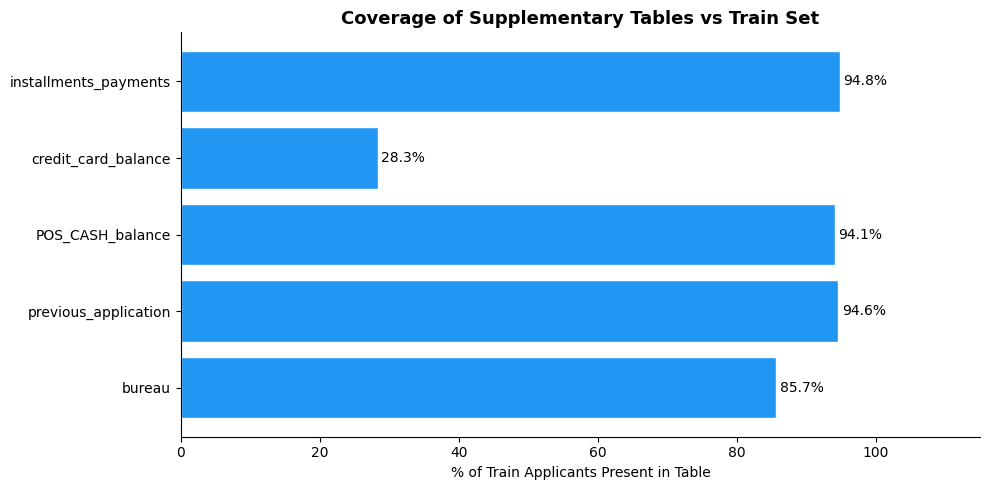

In [36]:
# Coverage: what % of train applicants appear in each secondary table
train_ids = set(train['SK_ID_CURR'])

coverage = {}
for name, df in tables.items():
    if name != 'application_train' and 'SK_ID_CURR' in df.columns:
        n_match = len(set(df['SK_ID_CURR']) & train_ids)
        coverage[name] = round(n_match / len(train_ids) * 100, 1)

fig, ax = plt.subplots(figsize=(10, 5))
names = list(coverage.keys())
vals  = list(coverage.values())
bars  = ax.barh(names, vals, color='#2196F3', edgecolor='white')
ax.set_xlabel('% of Train Applicants Present in Table')
ax.set_title('Coverage of Supplementary Tables vs Train Set', fontsize=13, fontweight='bold')
for bar, val in zip(bars, vals):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%',
            va='center', fontsize=10)
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

---
## 10. Key EDA Takeaways & Feature Engineering Directions

### What we learned:

**Class Imbalance**
- Only ~8% of applicants defaulted. Models must account for this (class weights, SMOTE, threshold tuning).

**Most Predictive Features in Main Table**
- `EXT_SOURCE_1/2/3` — externally computed scores, strongest signal. Higher = less likely to default.
- `DAYS_BIRTH` (age) — younger applicants default more.
- `DAYS_EMPLOYED` — longer employment tenure = fewer defaults.
- `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE` — loan structure features.

**Missing Values**
- Several columns have 40–70% missing (especially `OCCUPATION_TYPE`, external scores). Need imputation strategy.

**Bureau Data**
- Applicants with more overdue bureau credits have higher default rates.
- Bureau credit count and status are useful aggregation features.

**Payment Behavior (Installments)**
- Defaulters have higher average days late and lower payment ratios.
- % of late payments is a good engineered feature.

**Credit Card Utilization**
- High credit utilization correlates with default.

### Feature Engineering Priorities:

1. Aggregate secondary tables by `SK_ID_CURR` (mean, max, sum, count of DPD, overdue, balances)
2. Create `CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL`
3. Create `ANNUITY_INCOME_RATIO = AMT_ANNUITY / AMT_INCOME_TOTAL`
4. Create `AGE_YEARS = -DAYS_BIRTH / 365`
5. Create `EMPLOYED_YEARS = -DAYS_EMPLOYED / 365` (flag anomaly at 365243)
6. Bureau: `% active credits`, `avg overdue per credit`, `years since last credit`
7. Installments: `avg days late`, `% late payments`, `avg payment ratio`
8. Credit card: `avg utilization`, `max DPD`, `avg balance`